# CLTV Prediction with BG-NBD and Gamma-Gamma
UCI Online Retail II dataset, UK customers, 6-month lifetime value forecast.

In [1]:
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PALETTE = ["#2E86AB", "#F24236", "#F6AE2D", "#5A2A27", "#88D18A"]


In [2]:
df_ = pd.read_excel("datasets/online_retail_II.xlsx", sheet_name="Year 2010-2011")
df = df_.copy()
df.shape


(541910, 8)

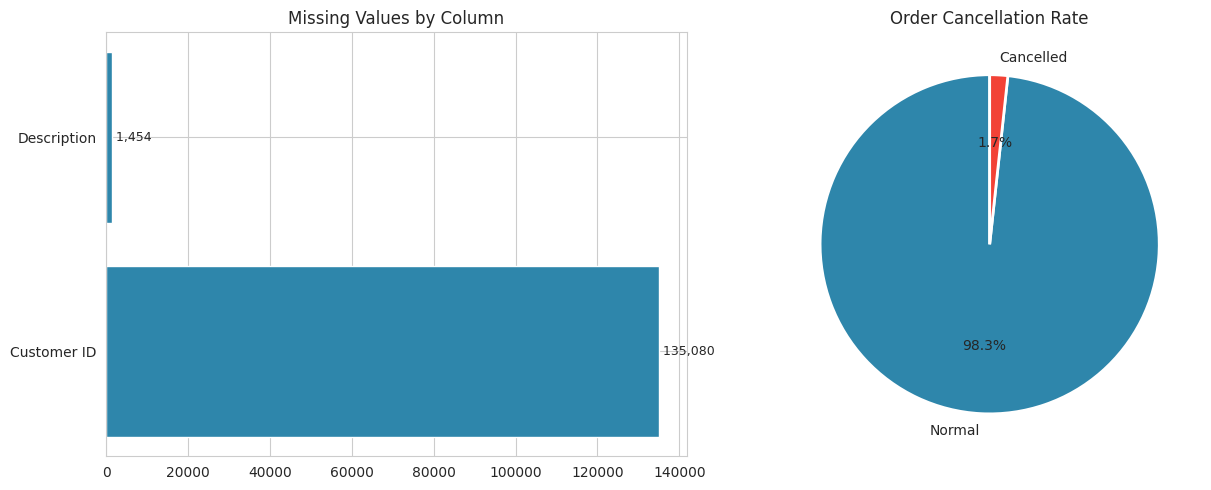

Missing Customer ID: 135,080 rows (25% of the data)
Cancelled invoices: 9,288 (1.7%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
axes[0].barh(missing.index, missing.values, color=PALETTE[0])
axes[0].set_title("Missing Values by Column")
for i, v in enumerate(missing.values):
    axes[0].text(v, i, f" {v:,}", va="center", fontsize=9)

is_cancel = df["Invoice"].astype(str).str.contains("C", na=False)
counts = is_cancel.value_counts().rename({False: "Normal", True: "Cancelled"})
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[PALETTE[0], PALETTE[1]], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Order Cancellation Rate")
plt.tight_layout()
plt.show()

print(f"Missing Customer ID: {df['Customer ID'].isnull().sum():,} rows ({df['Customer ID'].isnull().mean()*100:.0f}% of the data)")
print(f"Cancelled invoices: {is_cancel.sum():,} ({is_cancel.mean()*100:.1f}%)")


A quarter of all rows have no `Customer ID`, so they can't be tied to a customer and have to be dropped. Cancellations are a small share (1.7%) and are excluded since they're refunds, not purchases.

In [4]:
df.dropna(inplace=True)
df = df[~df["Invoice"].astype(str).str.contains("C", na=False)]
df = df[df["Quantity"] > 0]
df.shape


(397925, 8)

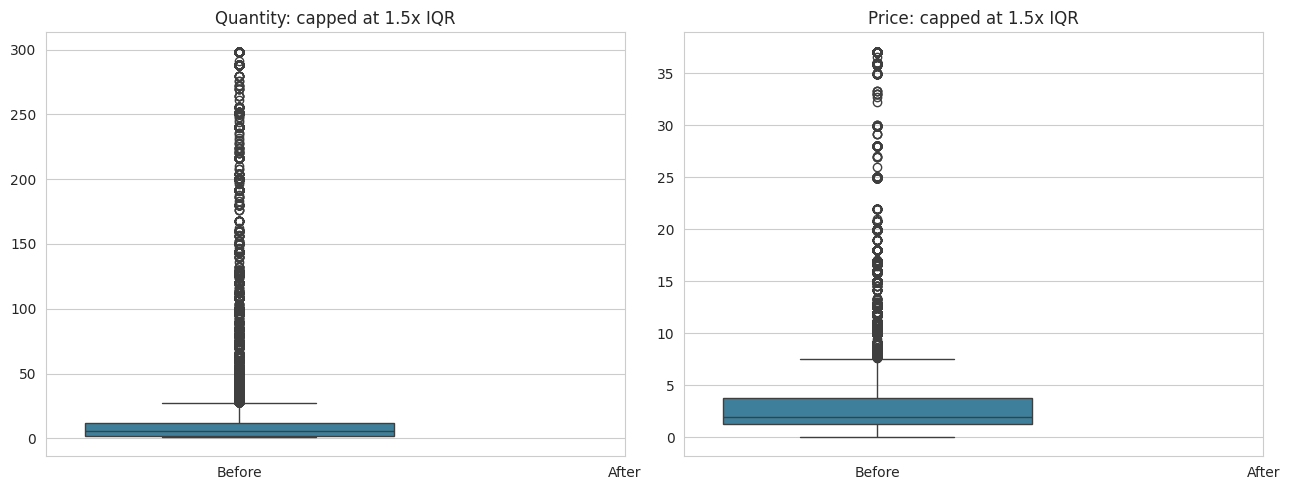

In [5]:
def outlier_thresholds(dataframe, variable):
    q1 = dataframe[variable].quantile(0.01)
    q3 = dataframe[variable].quantile(0.99)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def replace_with_thresholds(dataframe, variable):
    low, up = outlier_thresholds(dataframe, variable)
    dataframe[variable] = dataframe[variable].astype(float)
    dataframe.loc[dataframe[variable] < low, variable] = low
    dataframe.loc[dataframe[variable] > up, variable] = up

before = df[["Quantity", "Price"]].copy()
replace_with_thresholds(df, "Quantity")
replace_with_thresholds(df, "Price")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ["Quantity", "Price"]):
    sns.boxplot(data=[before[col], df[col]], ax=ax, color=PALETTE[0])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Before", "After"])
    ax.set_title(f"{col}: capped at 1.5x IQR")
plt.tight_layout()
plt.show()


Bulk orders (up to 80,995 units in a single line) and a few outlier prices were skewing the average purchase value. Capping them keeps the shape of the distribution intact and stops a handful of rows from distorting every customer's `monetary_value`.

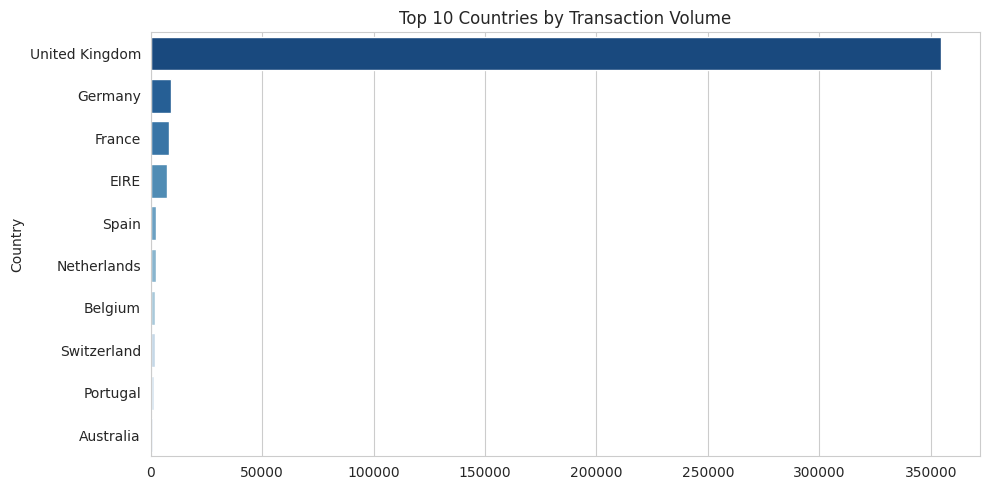

UK share of transactions: 89.0%


(354345, 8)

In [6]:
country_counts = df["Country"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette="Blues_r", legend=False)
plt.title("Top 10 Countries by Transaction Volume")
plt.tight_layout()
plt.show()

uk_share = df["Country"].eq("United Kingdom").mean()
print(f"UK share of transactions: {uk_share*100:.1f}%")

df = df[df["Country"] == "United Kingdom"]
df.shape


The UK makes up the large majority of transactions, and every other country is a small fraction of it — mixing them in would mean modeling mostly-UK behavior with noise from a dozen tiny, structurally different markets. Restricting to the UK gives a cleaner, more comparable customer base.

In [7]:
df["TotalPrice"] = df["Quantity"] * df["Price"]
today_date = dt.datetime(2011, 12, 11)

cltv_df = df.groupby("Customer ID").agg({
    "InvoiceDate": [lambda d: (d.max() - d.min()).days / 7,
                    lambda d: (today_date - d.min()).days / 7],
    "Invoice": lambda x: x.nunique(),
    "TotalPrice": lambda x: x.sum()
})
cltv_df.columns = cltv_df.columns.droplevel(0)
cltv_df.columns = ["recency", "T", "frequency", "monetary_value"]

cltv_df["monetary_value"] = cltv_df["monetary_value"] / cltv_df["frequency"]
cltv_df = cltv_df[cltv_df["monetary_value"] > 0]
cltv_df = cltv_df[cltv_df["frequency"] > 1]

cltv_df.describe().T


,count,mean,std,min,25%,50%,75%,max
recency,2570.00,28.55,16.24,0.00,14.43,29.86,42.71,53.29
T,2570.00,37.08,14.74,0.43,28.18,40.57,51.29,53.43
frequency,2570.00,5.95,8.41,2.00,2.00,4.00,6.00,210.00
monetary_value,2570.00,346.01,283.01,3.45,187.14,290.19,416.31,3864.55


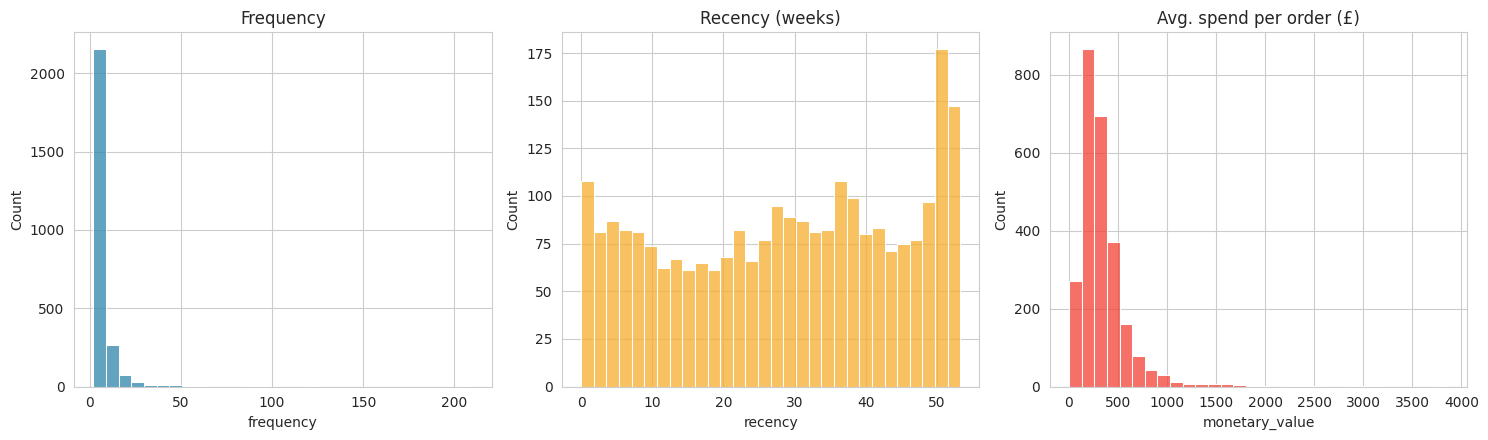

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(cltv_df["frequency"], bins=30, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Frequency")
sns.histplot(cltv_df["recency"], bins=30, color=PALETTE[2], ax=axes[1])
axes[1].set_title("Recency (weeks)")
sns.histplot(cltv_df["monetary_value"], bins=30, color=PALETTE[1], ax=axes[2])
axes[2].set_title("Avg. spend per order (£)")
plt.tight_layout()
plt.show()


Out of the full UK customer base, only repeat buyers (2 or more orders) qualify for this model — one-time shoppers don't have enough history for BG-NBD to learn a pattern from. The frequency distribution is heavily right-skewed: most customers buy just a handful of times, and a small tail buys constantly, which is exactly the pattern BG-NBD is built to model.

In [9]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(cltv_df["frequency"], cltv_df["recency"], cltv_df["T"])
bgf


<lifetimes.BetaGeoFitter: fitted with 2570 subjects, a: 0.12, alpha: 11.66, b: 2.51, r: 2.21>

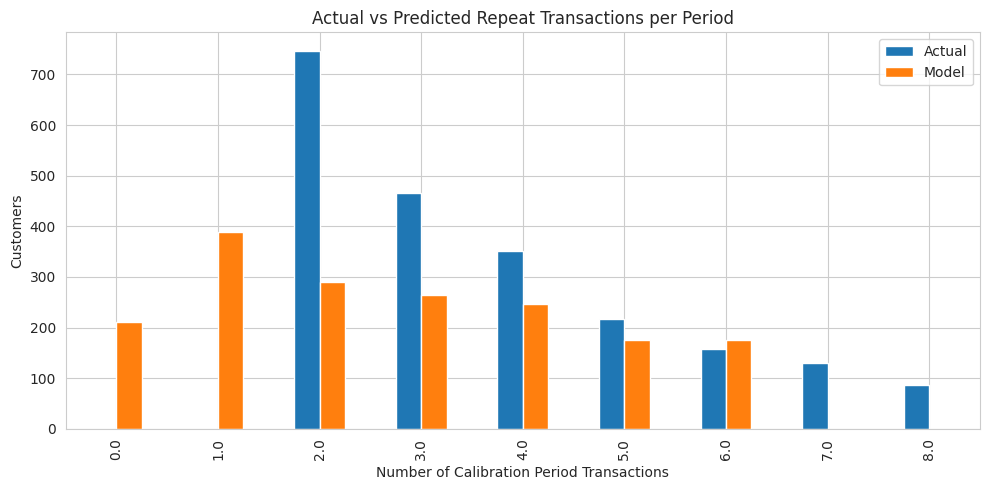

In [10]:
ax = plot_period_transactions(bgf)
ax.set_title("Actual vs Predicted Repeat Transactions per Period")
plt.tight_layout()
plt.show()


The predicted curve tracks the actual transaction counts closely, which means the model's assumptions hold reasonably well for this customer base and its purchase predictions can be trusted.

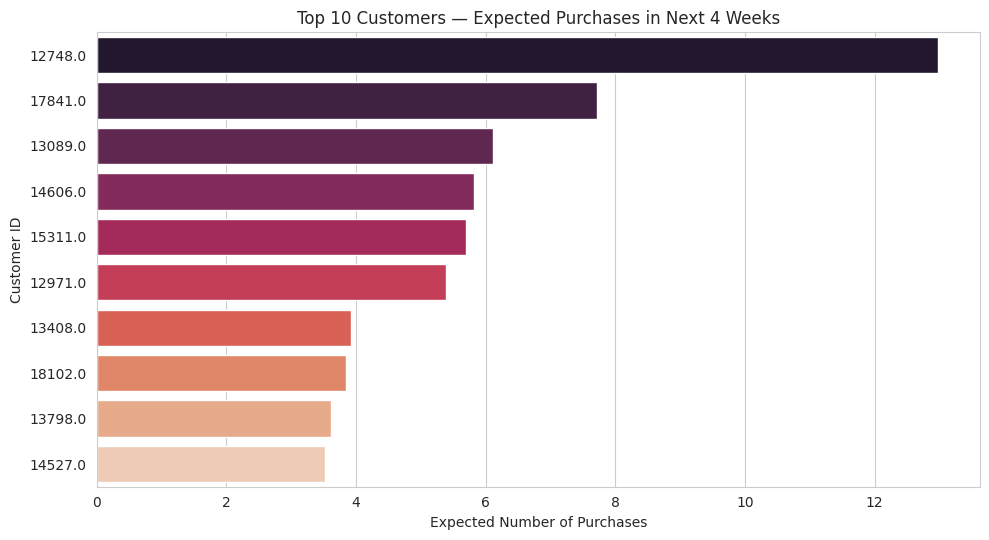

In [11]:
cltv_df["expected_purc_1_week"] = bgf.predict(1, cltv_df["frequency"], cltv_df["recency"], cltv_df["T"])
cltv_df["expected_purc_1_month"] = bgf.predict(4, cltv_df["frequency"], cltv_df["recency"], cltv_df["T"])

top10_purchase = cltv_df.sort_values("expected_purc_1_month", ascending=False).head(10)

plt.figure(figsize=(10, 5.5))
sns.barplot(x=top10_purchase["expected_purc_1_month"], y=top10_purchase.index.astype(str), hue=top10_purchase.index.astype(str), palette="rocket", legend=False)
plt.title("Top 10 Customers — Expected Purchases in Next 4 Weeks")
plt.xlabel("Expected Number of Purchases")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()


In [12]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(cltv_df["frequency"], cltv_df["monetary_value"])
cltv_df["exp_avg_profit"] = ggf.conditional_expected_average_profit(cltv_df["frequency"], cltv_df["monetary_value"])
cltv_df.sort_values("exp_avg_profit", ascending=False).head(10)


,recency,T,frequency,monetary_value,expected_purc_1_week,expected_purc_1_month,exp_avg_profit
Customer ID,,,,,,,
14088.00,44.57,46.14,13,3864.55,0.26,1.04,3916.38
18102.00,52.29,52.57,60,3859.74,0.97,3.85,3870.84
15749.00,13.86,47.57,3,3028.78,0.03,0.11,3213.27
14096.00,13.86,14.57,17,3163.59,0.72,2.87,3195.97
17511.00,52.86,53.43,31,2933.94,0.51,2.02,2950.35
17450.00,51.29,52.57,46,2863.27,0.75,2.97,2874.05
13081.00,51.29,53.14,11,2576.13,0.20,0.80,2617.17
16000.00,0.00,0.43,3,2335.12,0.42,1.64,2477.66
16984.00,5.86,18.71,2,2240.68,0.10,0.41,2452.32


In [13]:
cltv = ggf.customer_lifetime_value(
    bgf,
    cltv_df["frequency"], cltv_df["recency"], cltv_df["T"], cltv_df["monetary_value"],
    time=6, freq="W", discount_rate=0.01
).reset_index()

cltv_final = cltv_df.merge(cltv, on="Customer ID", how="left")
top10_clv = cltv_final.sort_values("clv", ascending=False).head(10)
top10_clv


,Customer ID,recency,T,frequency,monetary_value,expected_purc_1_week,expected_purc_1_month,exp_avg_profit,clv
2486,18102.00,52.29,52.57,60,3859.74,0.97,3.85,3870.84,92217.94
589,14096.00,13.86,14.57,17,3163.59,0.72,2.87,3195.97,55730.60
2184,17450.00,51.29,52.57,46,2863.27,0.75,2.97,2874.05,52847.59
2213,17511.00,52.86,53.43,31,2933.94,0.51,2.02,2950.35,36948.19
1804,16684.00,50.43,51.29,28,2209.97,0.48,1.90,2223.69,26147.00
406,13694.00,52.71,53.43,50,1275.70,0.80,3.18,1280.16,25225.65
587,14088.00,44.57,46.14,13,3864.55,0.26,1.04,3916.38,25042.44
1485,16000.00,0.00,0.43,3,2335.12,0.42,1.64,2477.66,23978.78
1173,15311.00,53.29,53.43,91,667.78,1.43,5.70,669.08,23597.87
133,13089.00,52.29,52.86,97,606.36,1.53,6.11,607.47,22972.27


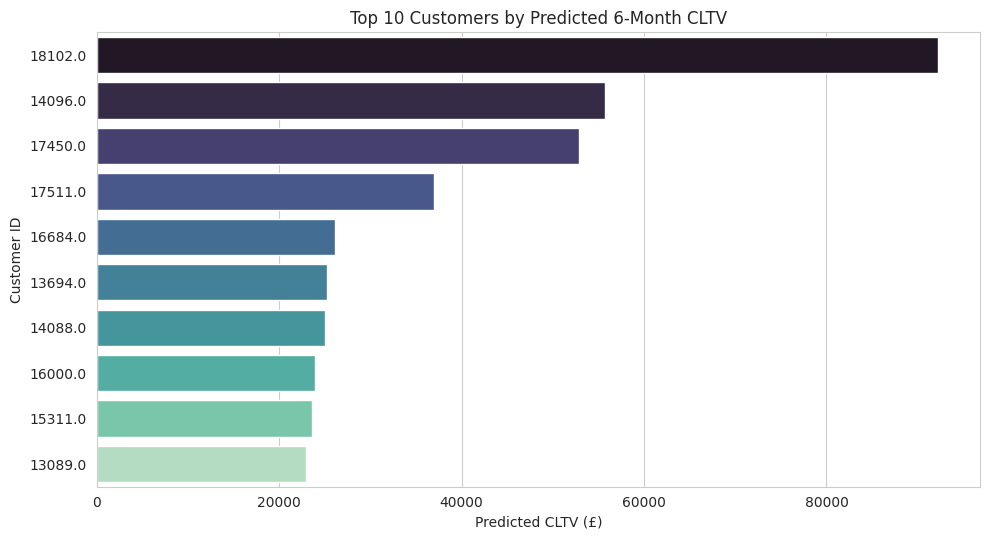

In [14]:
plt.figure(figsize=(10, 5.5))
sns.barplot(x=top10_clv["clv"], y=top10_clv["Customer ID"].astype(str), hue=top10_clv["Customer ID"].astype(str), palette="mako", legend=False)
plt.title("Top 10 Customers by Predicted 6-Month CLTV")
plt.xlabel("Predicted CLTV (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()


The top customer's predicted value is roughly double the second-highest — that gap comes from combining both high order frequency and a high average order value, not just one or the other. CLTV rewards customers who are strong on both dimensions.

In [15]:
scaler = MinMaxScaler(feature_range=(0, 1))
cltv_final["scaled_clv"] = scaler.fit_transform(cltv_final[["clv"]])
cltv_final["Segment"] = pd.qcut(cltv_final["scaled_clv"], 4, labels=["D", "C", "B", "A"])

segment_summary = cltv_final.groupby("Segment", observed=True).agg(
    customer_count=("clv", "count"),
    avg_clv=("clv", "mean"),
    total_clv=("clv", "sum"),
).sort_index()
segment_summary


,customer_count,avg_clv,total_clv
Segment,,,
D,643,270.54,173954.93
C,642,712.49,457419.13
B,642,1274.29,818094.42
A,643,3853.53,2477817.99


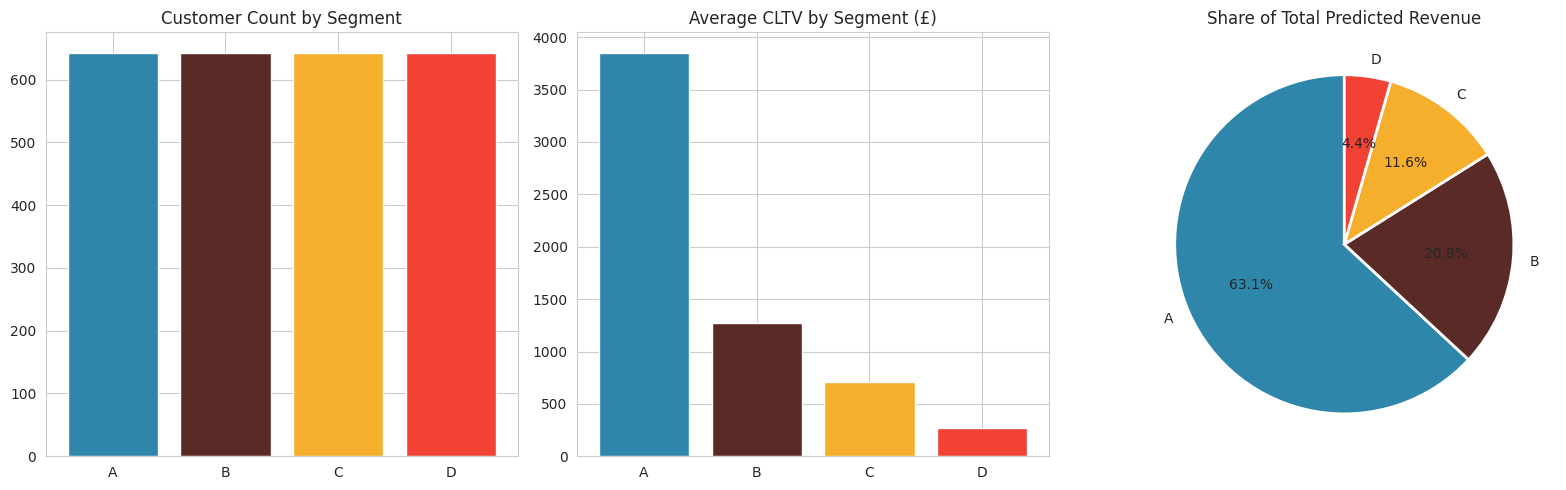

Segment A: 643 customers, 63% of predicted revenue
Segment D: 643 customers, 4% of predicted revenue


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
seg_colors = {"A": "#2E86AB", "B": "#5A2A27", "C": "#F6AE2D", "D": "#F24236"}
order = ["A", "B", "C", "D"]

axes[0].bar(order, [segment_summary.loc[s, "customer_count"] for s in order], color=[seg_colors[s] for s in order])
axes[0].set_title("Customer Count by Segment")

axes[1].bar(order, [segment_summary.loc[s, "avg_clv"] for s in order], color=[seg_colors[s] for s in order])
axes[1].set_title("Average CLTV by Segment (£)")

axes[2].pie([segment_summary.loc[s, "total_clv"] for s in order], labels=order,
            colors=[seg_colors[s] for s in order], autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[2].set_title("Share of Total Predicted Revenue")
plt.tight_layout()
plt.show()

a_share = segment_summary.loc["A", "total_clv"] / segment_summary["total_clv"].sum()
d_share = segment_summary.loc["D", "total_clv"] / segment_summary["total_clv"].sum()
print(f"Segment A: {segment_summary.loc['A','customer_count']} customers, {a_share*100:.0f}% of predicted revenue")
print(f"Segment D: {segment_summary.loc['D','customer_count']} customers, {d_share*100:.0f}% of predicted revenue")


The four segments are equal in size by construction (quartiles), but not in value: Segment A alone accounts for well over half of total predicted revenue, while Segment D — the same number of customers — contributes only a few percent. That gap is the actual business case for treating these groups differently: retention spend belongs on A and B, not spread evenly across the base.